# Data preprocessing

In [2]:
# Import pandas 
import pandas as pd

In [3]:
df=pd.read_csv('Financials.csv')

In [4]:
df

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,161850,300,2000,3237000,$-,3237000,1618500,1618500.0,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,132100,300,2000,2642000,$-,2642000,1321000,1321000.0,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,217800,300,1500,3267000,$-,3267000,2178000,1089000.0,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,88800,300,1500,1332000,$-,1332000,888000,444000.0,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,247000,300,1500,3705000,$-,3705000,2470000,1235000.0,01/06/2014,6,June,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,247500,26000,30000,74250000,"$1,11,375.00",63112500,61875000,1237500.0,01/03/2014,3,March,2014
696,Small Business,Mexico,Amarilla,High,54600,26000,30000,16380000,"$24,570.00",13923000,13650000,273000.0,01/10/2014,10,October,2014
697,Government,Mexico,Montana,High,136800,500,700,957600,"$1,436.40",813960,684000,129960.0,01/02/2014,2,February,2014
698,Government,Canada,Paseo,High,72300,1000,700,506100,$759.15,430185,361500,68685.0,01/04/2014,4,April,2014


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        700 non-null    object 
 4   Units Sold           700 non-null    int64  
 5   Manufacturing Price  700 non-null    int64  
 6   Sale Price           700 non-null    int64  
 7   Gross Sales          700 non-null    int64  
 8   Discounts            700 non-null    object 
 9   Sales                700 non-null    int64  
 10  COGS                 700 non-null    int64  
 11  Profit               695 non-null    float64
 12  Date                 700 non-null    object 
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    object 
 15  Year                 700 non-null    int

In [6]:
df.isna().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 5
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

In [7]:
df=df.dropna()

In [8]:
df.isna().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

In [9]:
df['Discounts']=df['Discounts'].str.replace('$','',regex=False)

/var/folders/_4/b9s2hms900bfwkkw9c61rv4w0000gn/T/ipykernel_32798/1194694242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Discounts']=df['Discounts'].str.replace('$','',regex=False)


In [10]:
df['Discounts']=df['Discounts'].str.replace('-','',regex=True)

/var/folders/_4/b9s2hms900bfwkkw9c61rv4w0000gn/T/ipykernel_32798/486270549.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Discounts']=df['Discounts'].str.replace('-','',regex=True)


In [11]:
df['Discounts'] = pd.to_numeric(df['Discounts'], errors='coerce')

/var/folders/_4/b9s2hms900bfwkkw9c61rv4w0000gn/T/ipykernel_32798/4287570994.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Discounts'] = pd.to_numeric(df['Discounts'], errors='coerce')


In [12]:
df.fillna(0, inplace=True)

/var/folders/_4/b9s2hms900bfwkkw9c61rv4w0000gn/T/ipykernel_32798/4231983114.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace=True)


In [13]:
# Dropping the 'Month Name' column
df=df.drop(columns=["Month Name"])

In [14]:
# Correcting the decimal points and adding 2 new varibales
df['Discounts'] = df['Discounts'] * 100
df['Units Sold'] = df['Units Sold'] / 100
df["Profit Margin"] = df["Profit"] / df["Sales"]
df["Profit Per Unit"] = df["Profit"] / df["Sales"]

In [15]:
df['Date']=pd.to_datetime(df['Date'], dayfirst=True)

In [16]:
import numpy as np

In [17]:


# Gross Sales outliers
Q1_gross_sales = df['Gross Sales'].quantile(0.25)
Q3_gross_sales = df['Gross Sales'].quantile(0.75)
IQR_gross_sales = Q3_gross_sales - Q1_gross_sales

# Define extreme outlier bounds for Gross Sales
lower_bound_gross_sales = Q1_gross_sales - 3 * IQR_gross_sales
upper_bound_gross_sales = Q3_gross_sales + 3 * IQR_gross_sales

# Replace extreme outliers in Gross Sales with the median
median_gross_sales = df['Gross Sales'].median()
df['Gross Sales'] = np.where((df['Gross Sales'] < lower_bound_gross_sales) | 
                             (df['Gross Sales'] > upper_bound_gross_sales), 
                             median_gross_sales, 
                             df['Gross Sales'])


In [18]:
# Sales outliers
Q1_sales = df['Sales'].quantile(0.25)
Q3_sales = df['Sales'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales

# Define extreme outlier bounds for Sales
lower_bound_sales = Q1_sales - 3 * IQR_sales
upper_bound_sales = Q3_sales + 3 * IQR_sales

# Replace extreme outliers in Sales with the median
median_sales = df['Sales'].median()
df['Sales'] = np.where((df['Sales'] < lower_bound_sales) | 
                       (df['Sales'] > upper_bound_sales), 
                       median_sales, 
                       df['Sales'])


In [19]:
# Profit outliers
Q1_profit = df['Profit'].quantile(0.25)
Q3_profit = df['Profit'].quantile(0.75)
IQR_profit = Q3_profit - Q1_profit

# Define extreme outlier bounds for Profit
lower_bound_profit = Q1_profit - 3 * IQR_profit
upper_bound_profit = Q3_profit + 3 * IQR_profit

# Replace extreme outliers in Profit with the median
median_profit = df['Profit'].median()
df['Profit'] = np.where((df['Profit'] < lower_bound_profit) | 
                        (df['Profit'] > upper_bound_profit), 
                        median_profit, 
                        df['Profit'])


In [20]:
df[(df['Profit'] < lower_bound_profit) | (df['Profit'] > upper_bound_profit)]

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year,Profit Margin,Profit Per Unit


In [21]:
df[(df['Sales'] < lower_bound_sales) | (df['Sales'] > upper_bound_sales)]

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year,Profit Margin,Profit Per Unit


In [22]:
df[(df['Gross Sales'] < lower_bound_gross_sales) | (df['Gross Sales'] > upper_bound_gross_sales)]

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year,Profit Margin,Profit Per Unit


In [23]:
df

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year,Profit Margin,Profit Per Unit
0,Government,Canada,Carretera,None,1618.5,300,2000,3237000.0,0.0,3237000.0,1618500,1618500.0,2014-01-01,1,2014,0.500000,0.500000
1,Government,Germany,Carretera,None,1321.0,300,2000,2642000.0,0.0,2642000.0,1321000,1321000.0,2014-01-01,1,2014,0.500000,0.500000
2,Midmarket,France,Carretera,None,2178.0,300,1500,3267000.0,0.0,3267000.0,2178000,1089000.0,2014-06-01,6,2014,0.333333,0.333333
3,Midmarket,Germany,Carretera,None,888.0,300,1500,1332000.0,0.0,1332000.0,888000,444000.0,2014-06-01,6,2014,0.333333,0.333333
4,Midmarket,Mexico,Carretera,None,2470.0,300,1500,3705000.0,0.0,3705000.0,2470000,1235000.0,2014-06-01,6,2014,0.333333,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,2475.0,26000,30000,74250000.0,0.0,63112500.0,61875000,1237500.0,2014-03-01,3,2014,0.019608,0.019608
696,Small Business,Mexico,Amarilla,High,546.0,26000,30000,16380000.0,0.0,13923000.0,13650000,273000.0,2014-10-01,10,2014,0.019608,0.019608
697,Government,Mexico,Montana,High,1368.0,500,700,957600.0,0.0,813960.0,684000,129960.0,2014-02-01,2,2014,0.159664,0.159664
698,Government,Canada,Paseo,High,723.0,1000,700,506100.0,75915.0,430185.0,361500,68685.0,2014-04-01,4,2014,0.159664,0.159664


In [24]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Units Sold,695.0,1609.601439,200.0,905.0,1545.0,2230.75,4492.5,867.81657
Manufacturing Price,695.0,9674.676259,300.0,500.0,1000.0,25000.0,26000.0,10861.176285
Sale Price,695.0,11838.129496,700.0,1200.0,2000.0,30000.0,35000.0,13726.619607
Gross Sales,695.0,17793512.733813,179900.0,1732500.0,3708000.0,26950000.0,104850000.0,24690583.773763
Discounts,695.0,11545.031655,0.0,0.0,0.0,0.0,98375.0,24993.000731
Sales,695.0,16226832.631655,165508.0,1585118.0,3473610.0,24359125.0,98681100.0,22540119.594071
COGS,695.0,14529019.856115,91800.0,748000.0,2198000.0,24590500.0,95062500.0,20442817.294521
Profit,695.0,1473021.854676,28560.0,401363.0,1113560.0,1770464.0,8161275.0,1611193.037342
Date,695,2014-04-28 07:29:36.690647552,2013-09-01 00:00:00,2013-12-01 00:00:00,2014-05-01 00:00:00,2014-09-01 00:00:00,2014-12-01 00:00:00,NaN
Month Number,695.0,7.902158,1.0,6.0,9.0,10.0,12.0,3.373773


In [25]:
# Defining the bins based on the provided values
bins = [28560, 401363, 1113560, 1770464, 8161275]
labels = ["Low", "Average", "Above Average", "High"]
# Creating the new category column
df['Profit Category'] = pd.cut(df['Profit'], bins=bins, labels=labels, include_lowest=True)

In [26]:
df

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year,Profit Margin,Profit Per Unit,Profit Category
0,Government,Canada,Carretera,None,1618.5,300,2000,3237000.0,0.0,3237000.0,1618500,1618500.0,2014-01-01,1,2014,0.500000,0.500000,Above Average
1,Government,Germany,Carretera,None,1321.0,300,2000,2642000.0,0.0,2642000.0,1321000,1321000.0,2014-01-01,1,2014,0.500000,0.500000,Above Average
2,Midmarket,France,Carretera,None,2178.0,300,1500,3267000.0,0.0,3267000.0,2178000,1089000.0,2014-06-01,6,2014,0.333333,0.333333,Average
3,Midmarket,Germany,Carretera,None,888.0,300,1500,1332000.0,0.0,1332000.0,888000,444000.0,2014-06-01,6,2014,0.333333,0.333333,Average
4,Midmarket,Mexico,Carretera,None,2470.0,300,1500,3705000.0,0.0,3705000.0,2470000,1235000.0,2014-06-01,6,2014,0.333333,0.333333,Above Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,2475.0,26000,30000,74250000.0,0.0,63112500.0,61875000,1237500.0,2014-03-01,3,2014,0.019608,0.019608,Above Average
696,Small Business,Mexico,Amarilla,High,546.0,26000,30000,16380000.0,0.0,13923000.0,13650000,273000.0,2014-10-01,10,2014,0.019608,0.019608,Low
697,Government,Mexico,Montana,High,1368.0,500,700,957600.0,0.0,813960.0,684000,129960.0,2014-02-01,2,2014,0.159664,0.159664,Low
698,Government,Canada,Paseo,High,723.0,1000,700,506100.0,75915.0,430185.0,361500,68685.0,2014-04-01,4,2014,0.159664,0.159664,Low


In [27]:
df.to_csv('FinancialsNew.csv',index=False)

# EDA using the new dataset 

In [29]:
FN=pd.read_csv('FinancialsNew.csv')

In [30]:
FN

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year,Profit Margin,Profit Per Unit,Profit Category
0,Government,Canada,Carretera,None,1618.5,300,2000,3237000.0,0.0,3237000.0,1618500,1618500.0,2014-01-01,1,2014,0.500000,0.500000,Above Average
1,Government,Germany,Carretera,None,1321.0,300,2000,2642000.0,0.0,2642000.0,1321000,1321000.0,2014-01-01,1,2014,0.500000,0.500000,Above Average
2,Midmarket,France,Carretera,None,2178.0,300,1500,3267000.0,0.0,3267000.0,2178000,1089000.0,2014-06-01,6,2014,0.333333,0.333333,Average
3,Midmarket,Germany,Carretera,None,888.0,300,1500,1332000.0,0.0,1332000.0,888000,444000.0,2014-06-01,6,2014,0.333333,0.333333,Average
4,Midmarket,Mexico,Carretera,None,2470.0,300,1500,3705000.0,0.0,3705000.0,2470000,1235000.0,2014-06-01,6,2014,0.333333,0.333333,Above Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690,Small Business,France,Amarilla,High,2475.0,26000,30000,74250000.0,0.0,63112500.0,61875000,1237500.0,2014-03-01,3,2014,0.019608,0.019608,Above Average
691,Small Business,Mexico,Amarilla,High,546.0,26000,30000,16380000.0,0.0,13923000.0,13650000,273000.0,2014-10-01,10,2014,0.019608,0.019608,Low
692,Government,Mexico,Montana,High,1368.0,500,700,957600.0,0.0,813960.0,684000,129960.0,2014-02-01,2,2014,0.159664,0.159664,Low
693,Government,Canada,Paseo,High,723.0,1000,700,506100.0,75915.0,430185.0,361500,68685.0,2014-04-01,4,2014,0.159664,0.159664,Low


In [31]:
# Step 1: Displaying descriptive statistics for key numeric variables
FN[["Units Sold", "Manufacturing Price", "Sale Price", 
    "Gross Sales", "Discounts", "Sales", "COGS", "Profit"]].describe().T.round()

,count,mean,std,min,25%,50%,75%,max
Units Sold,695.0,1610.0,868.0,200.0,905.0,1545.0,2231.0,4492.0
Manufacturing Price,695.0,9675.0,10861.0,300.0,500.0,1000.0,25000.0,26000.0
Sale Price,695.0,11838.0,13727.0,700.0,1200.0,2000.0,30000.0,35000.0
Gross Sales,695.0,17793513.0,24690584.0,179900.0,1732500.0,3708000.0,26950000.0,104850000.0
Discounts,695.0,11545.0,24993.0,0.0,0.0,0.0,0.0,98375.0
Sales,695.0,16226833.0,22540120.0,165508.0,1585118.0,3473610.0,24359125.0,98681100.0
COGS,695.0,14529020.0,20442817.0,91800.0,748000.0,2198000.0,24590500.0,95062500.0
Profit,695.0,1473022.0,1611193.0,28560.0,401363.0,1113560.0,1770464.0,8161275.0


In [32]:
import seaborn as sns

<Axes: xlabel='Profit', ylabel='Count'>

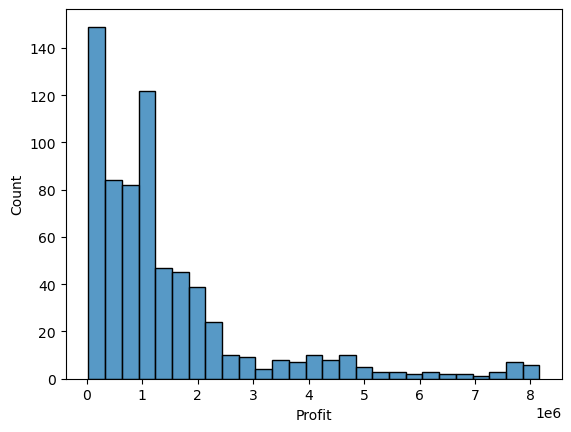

In [33]:
# Profit Distribution
sns.histplot(data=FN, x="Profit")

<Axes: xlabel='Segment', ylabel='count'>

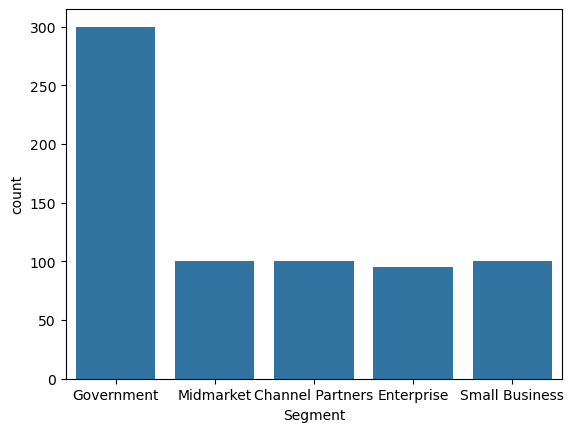

In [34]:
# Count of Segment
sns.countplot(data=FN, x="Segment")

<Axes: xlabel='Country', ylabel='count'>

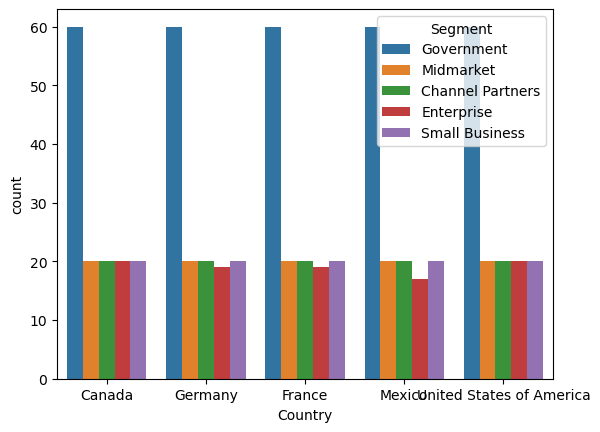

In [35]:
# Count of Country by Segment
sns.countplot(data=FN, x="Country", hue="Segment")

<Axes: xlabel='Units Sold', ylabel='Profit'>

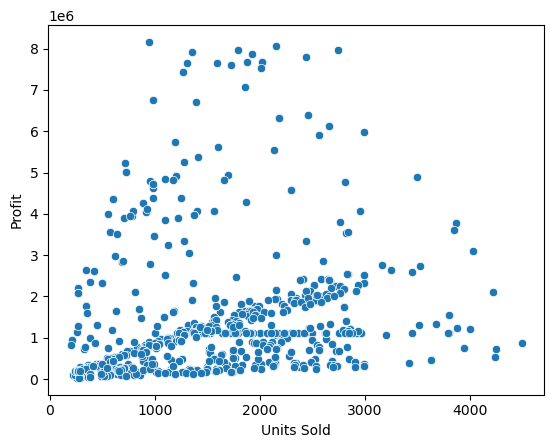

In [36]:
# Profit vs Units Sold
sns.scatterplot(data=FN, x="Units Sold", y="Profit")

<Axes: xlabel='Gross Sales', ylabel='Profit'>

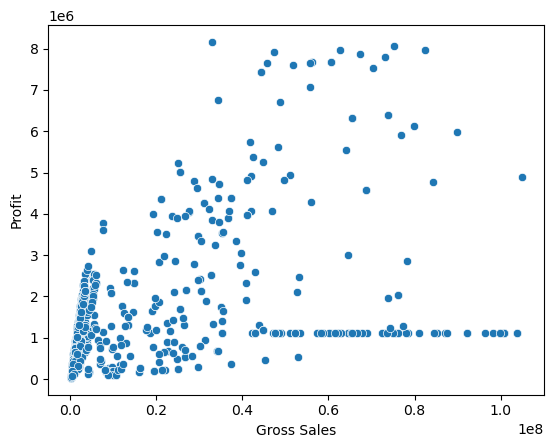

In [37]:
# Profit vs Gross Sales
sns.scatterplot(data=FN, x="Gross Sales", y="Profit")

<Axes: xlabel='Month Number', ylabel='Profit'>

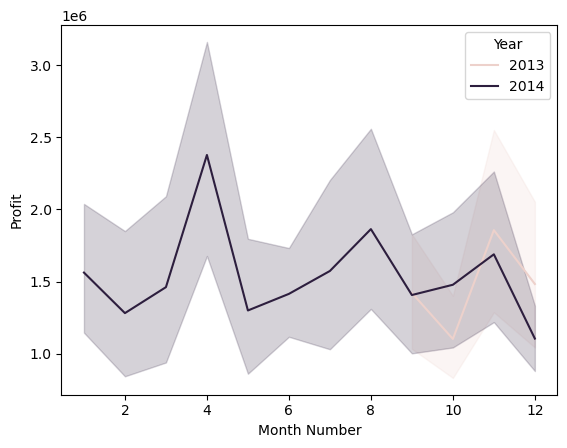

In [38]:
# Monthly Profit by Year
sns.lineplot(data=FN, x="Month Number", y="Profit", hue="Year")

In [41]:
correlation_matrix = FN[["Units Sold", "Manufacturing Price", "Sale Price", 
                         "Gross Sales", "Discounts", "Sales", "COGS", "Profit"]].corr()

In [42]:
correlation_matrix

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit
Units Sold,1.000000,-0.029040,-0.065198,0.289659,-0.222192,0.275714,0.330158,0.167383
Manufacturing Price,-0.029040,1.000000,0.071155,0.061761,-0.013529,0.054158,0.048051,0.028089
Sale Price,-0.065198,0.071155,1.000000,0.806789,-0.330293,0.799136,0.799965,0.536838
Gross Sales,0.289659,0.061761,0.806789,1.000000,-0.297688,0.974277,0.951635,0.479441
Discounts,-0.222192,-0.013529,-0.330293,-0.297688,1.000000,-0.295281,-0.299611,-0.264895
Sales,0.275714,0.054158,0.799136,0.974277,-0.295281,1.000000,0.930004,0.478385
COGS,0.330158,0.048051,0.799965,0.951635,-0.299611,0.930004,1.000000,0.457872
Profit,0.167383,0.028089,0.536838,0.479441,-0.264895,0.478385,0.457872,1.000000


<Axes: >

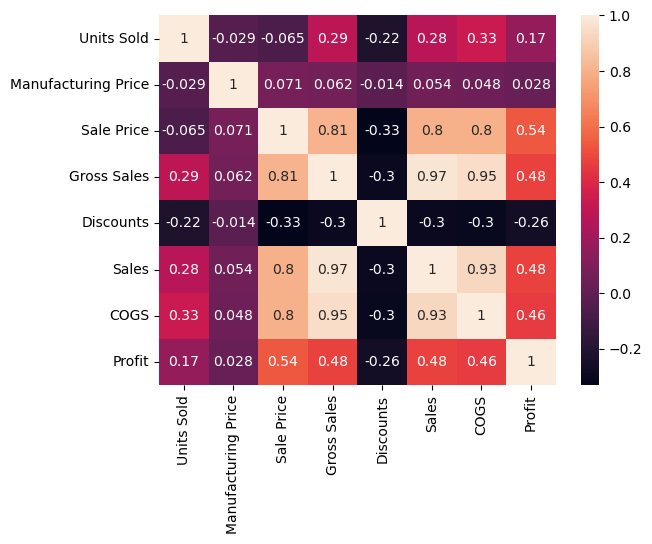

In [43]:
sns.heatmap(correlation_matrix, annot=True)

<Axes: xlabel='Segment', ylabel='Month Number'>

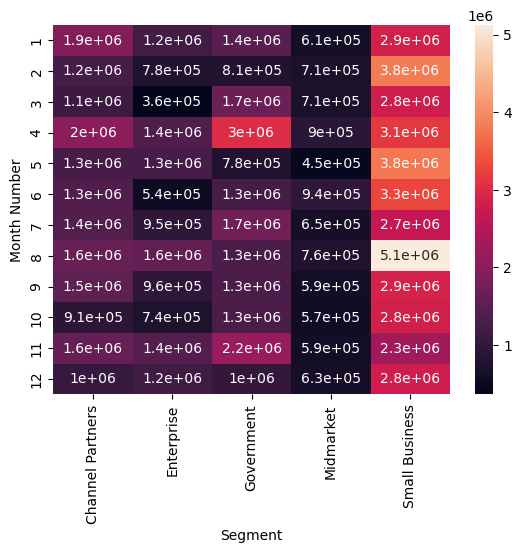

In [44]:
monthly_segment_profit = FN.groupby(["Month Number", "Segment"])["Profit"].mean().unstack()
sns.heatmap(monthly_segment_profit, annot=True)


<Axes: xlabel='Profit Margin', ylabel='Count'>

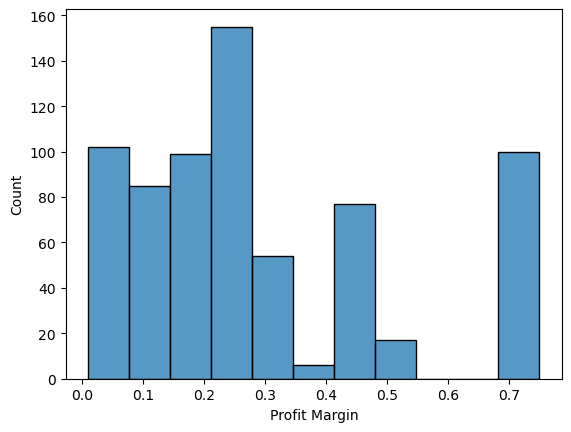

In [45]:
sns.histplot(FN["Profit Margin"])

<Axes: xlabel='Profit Per Unit', ylabel='Count'>

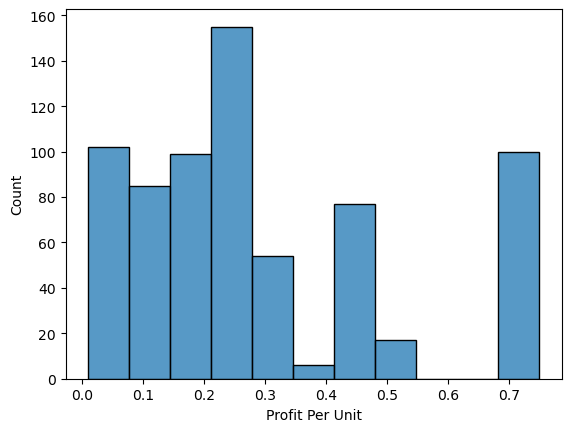

In [46]:
sns.histplot(FN["Profit Per Unit"])

<Axes: xlabel='Discount Band', ylabel='count'>

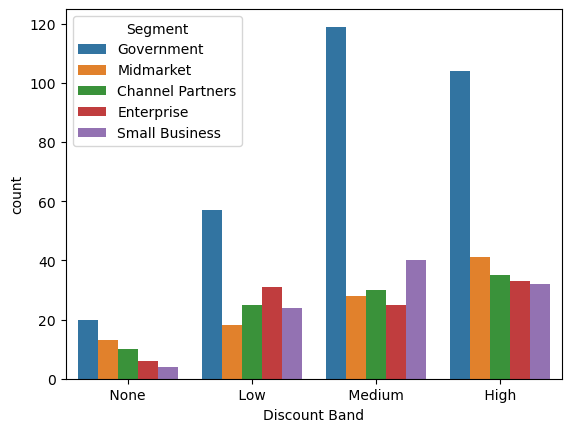

In [47]:
sns.countplot(data=FN, x="Discount Band", hue="Segment")